**Project: Predicting Uber Ride Cancellations**

https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard

**DAY 1 : DATASET UNDERSTANDING AND PREPROCESSING**



*   Download dataset
*   Load CSV using pandas
*   Understand columns using info() and describe()
*   Check missing Values
*   Convert Date and Time columns
*   Create datetime features ( hour,day, month, weekday, is_weekend )
*   Create cancellation flags
*   Handle missing values



**OUTPUT :** Cleansed and prepared dataset




In [5]:
!pip install opendatasets

In [6]:
import opendatasets as od
import opendatasets as od
import pandas as pd

od. download("https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard")

Skipping, found downloaded files in "./uber-ride-analytics-dashboard" (use force=True to force download)


In [7]:
!pip install opendatasets
import pandas as pd
import numpy as np

df = pd.read_csv("/content/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")
print("Shape:", df.shape)
df.head()

Shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [8]:
print(df.columns.tolist())
df.info()

['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type              

In [9]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [10]:
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

Duplicates: 0
After removing duplicates: (150000, 21)


In [11]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

print(df[['Date', 'Time']].dtypes)
df[['Date', 'Time']].head()

Date    datetime64[ns]
Time    datetime64[ns]
dtype: object


,Date,Time
0,2024-03-23,1900-01-01 12:29:38
1,2024-11-29,1900-01-01 18:01:39
2,2024-08-23,1900-01-01 08:56:10
3,2024-10-21,1900-01-01 17:17:25
4,2024-09-16,1900-01-01 22:08:00


In [13]:
df['booking_hour']    = df['Time'].dt.hour
df['booking_day']     = df['Date'].dt.day
df['booking_month']   = df['Date'].dt.month
df['booking_weekday'] = df['Date'].dt.dayofweek
df['is_weekend']      = df['booking_weekday'].isin([5, 6]).astype(int)

df[['Date', 'Time', 'booking_hour', 'booking_day',
    'booking_month', 'booking_weekday', 'is_weekend']].head(10)

,Date,Time,booking_hour,booking_day,booking_month,booking_weekday,is_weekend
0,2024-03-23,1900-01-01 12:29:38,12,23,3,5,1
1,2024-11-29,1900-01-01 18:01:39,18,29,11,4,0
2,2024-08-23,1900-01-01 08:56:10,8,23,8,4,0
3,2024-10-21,1900-01-01 17:17:25,17,21,10,0,0
4,2024-09-16,1900-01-01 22:08:00,22,16,9,0,0
5,2024-02-06,1900-01-01 09:44:56,9,6,2,1,0
6,2024-06-17,1900-01-01 15:45:58,15,17,6,0,0
7,2024-03-19,1900-01-01 17:37:37,17,19,3,1,0
8,2024-09-14,1900-01-01 12:49:09,12,14,9,5,1
9,2024-12-16,1900-01-01 19:06:48,19,16,12,0,0


In [14]:
# ONLY customer cancellations = 1, everything else = 0
df['is_cancelled'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)

print("Target distribution:")
print(df['is_cancelled'].value_counts())
print(f"\nCancellation Rate: {df['is_cancelled'].mean()*100:.2f}%")

Target distribution:
is_cancelled
0    139500
1     10500
Name: count, dtype: int64

Cancellation Rate: 7.00%


In [15]:
# Only fill safe numeric columns with mean
safe_num_cols = ['Avg VTAT', 'Booking Value', 'Ride Distance',
                 'Driver Ratings', 'Customer Rating']

for col in safe_num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill Vehicle Type and Payment Method with mode
df['Vehicle Type'].fillna(df['Vehicle Type'].mode()[0], inplace=True)

# DO NOT fill Payment Method — missing = cancelled ride (leakage)
# We will drop it later

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                                  0
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                             0
Ride Distance                             0
Driver Ratings                            0
Customer Rating                           0
Payment Method                        48000
booking_hour                              0
b

/tmp/ipykernel_1536/728944869.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_1536/728944869.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [16]:
df.to_csv("/content/uber_cleaned_day1.csv", index=False)
print("Day 1 Complete! Saved.")
print("Shape:", df.shape)
df.head()

Day 1 Complete! Saved.
Shape: (150000, 27)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Ride Distance,Driver Ratings,Customer Rating,Payment Method,booking_hour,booking_day,booking_month,booking_weekday,is_weekend,is_cancelled
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.456352,NaN,...,24.637012,4.230992,4.404584,NaN,12,23,3,5,1,0
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.900000,14.0,...,5.730000,4.230992,4.404584,UPI,18,29,11,4,0,0
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.400000,25.8,...,13.580000,4.900000,4.900000,Debit Card,8,23,8,4,0,0
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.100000,28.5,...,34.020000,4.600000,5.000000,UPI,17,21,10,0,0,0
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.300000,19.6,...,48.210000,4.100000,4.300000,UPI,22,16,9,0,0,0


**DAY 2 — Exploratory Data Analysis (EDA)**

In [17]:
#Load Cleaned Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/uber_cleaned_day1.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
print("Shape:", df.shape)
df.head()

Shape: (150000, 27)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Ride Distance,Driver Ratings,Customer Rating,Payment Method,booking_hour,booking_day,booking_month,booking_weekday,is_weekend,is_cancelled
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.456352,NaN,...,24.637012,4.230992,4.404584,NaN,12,23,3,5,1,0
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.900000,14.0,...,5.730000,4.230992,4.404584,UPI,18,29,11,4,0,0
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.400000,25.8,...,13.580000,4.900000,4.900000,Debit Card,8,23,8,4,0,0
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.100000,28.5,...,34.020000,4.600000,5.000000,UPI,17,21,10,0,0,0
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.300000,19.6,...,48.210000,4.100000,4.300000,UPI,22,16,9,0,0,0


In [18]:
#Understand Target Variable (Booking Status)
print("Booking Status Distribution:")
print(df['Booking Status'].value_counts())
print()
print("is_cancelled distribution:")
print(df['is_cancelled'].value_counts())

Booking Status Distribution:
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

is_cancelled distribution:
is_cancelled
0    139500
1     10500
Name: count, dtype: int64


/tmp/ipykernel_1536/2428623646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Booking Status', palette='Set2')


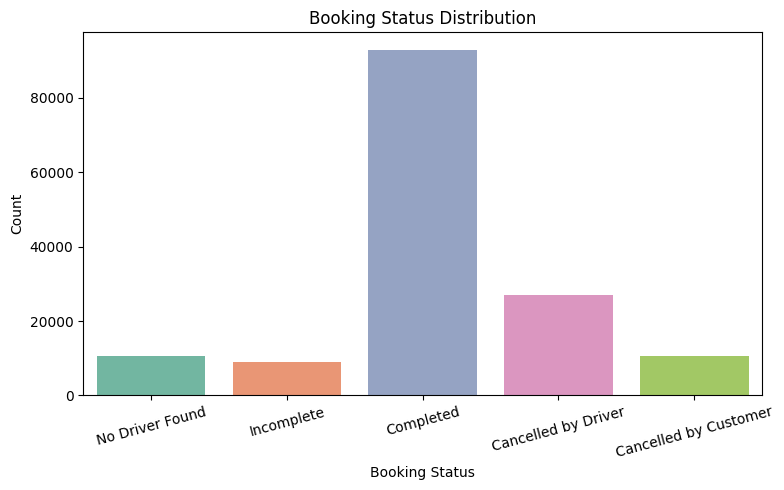

In [19]:
# Analyze Cancellation Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Booking Status', palette='Set2')
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

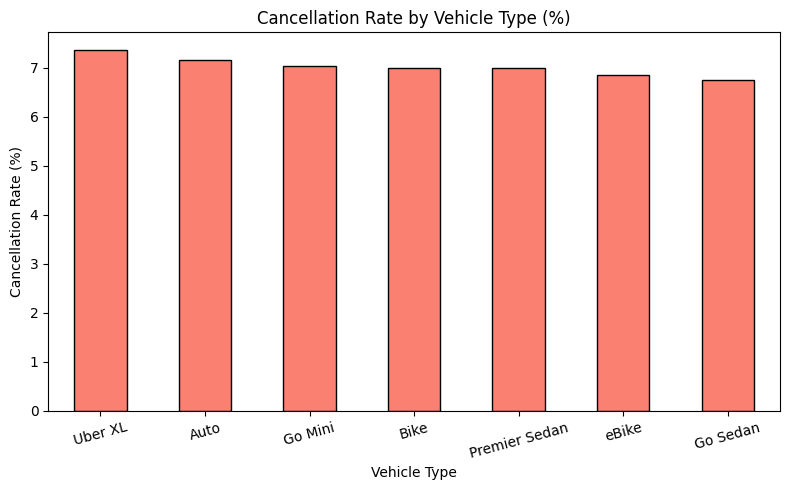

In [20]:
#Cancellation Rate by Vehicle Type
vehicle_cancel = df.groupby('Vehicle Type')['is_cancelled'].mean() * 100
vehicle_cancel = vehicle_cancel.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
vehicle_cancel.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Cancellation Rate by Vehicle Type (%)")
plt.xlabel("Vehicle Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

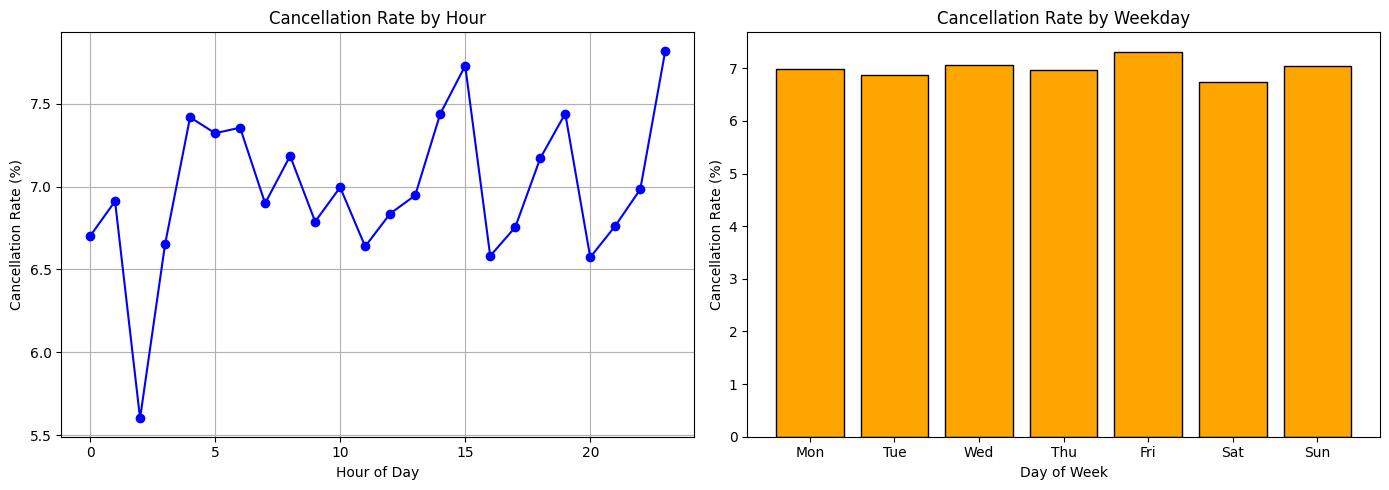

In [21]:
#Cancellation by Hour and Weekday
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_cancel = df.groupby('booking_hour')['is_cancelled'].mean() * 100
axes[0].plot(hour_cancel.index, hour_cancel.values, marker='o', color='blue')
axes[0].set_title("Cancellation Rate by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].grid(True)

weekday_cancel = df.groupby('booking_weekday')['is_cancelled'].mean() * 100
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(day_names, weekday_cancel.values, color='orange', edgecolor='black')
axes[1].set_title("Cancellation Rate by Weekday")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()

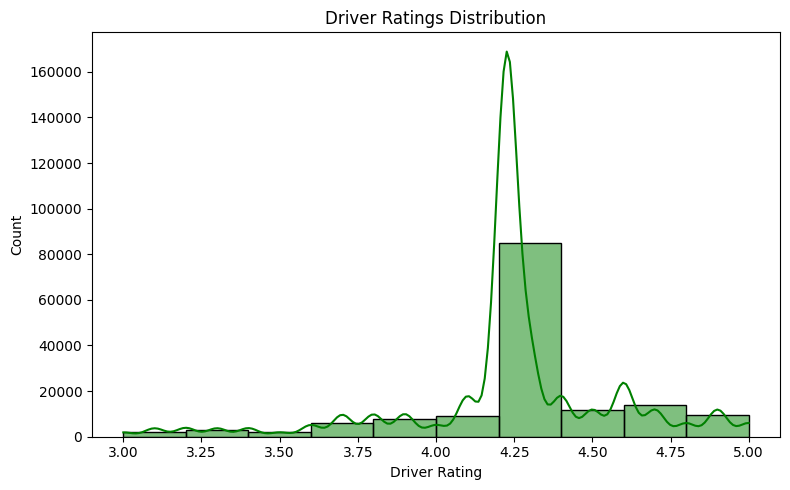

Avg Driver Rating (All)      : 4.23
Avg Rating (Cancelled)       : 4.23
Avg Rating (Completed)       : 4.23


In [22]:
#Driver Rating Analysis
plt.figure(figsize=(8, 5))
sns.histplot(df['Driver Ratings'].dropna(), bins=10, kde=True, color='green')
plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Avg Driver Rating (All)      :", df['Driver Ratings'].mean().round(2))
print("Avg Rating (Cancelled)       :", df[df['is_cancelled']==1]['Driver Ratings'].mean().round(2))
print("Avg Rating (Completed)       :", df[df['is_cancelled']==0]['Driver Ratings'].mean().round(2))

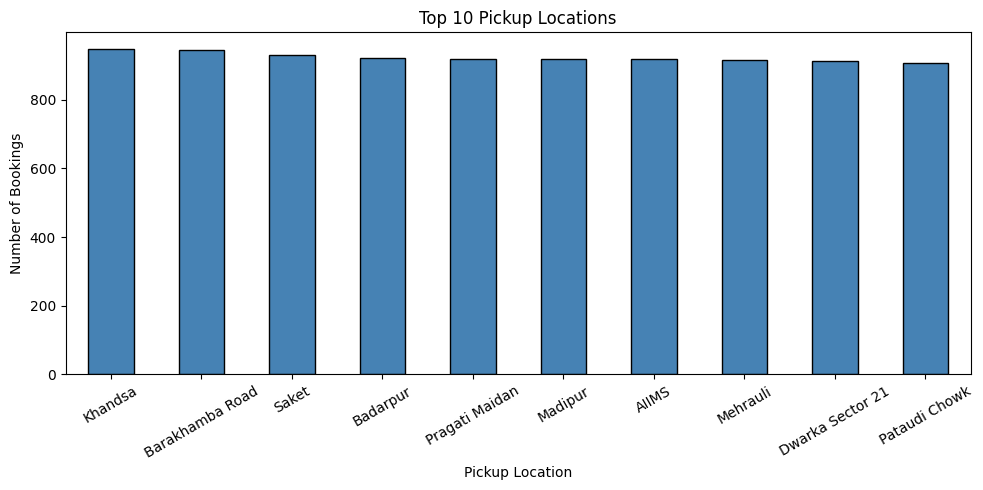

In [23]:
#Top Pickup Location Analysis
top_pickups = df['Pickup Location'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_pickups.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Top 10 Pickup Locations")
plt.xlabel("Pickup Location")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

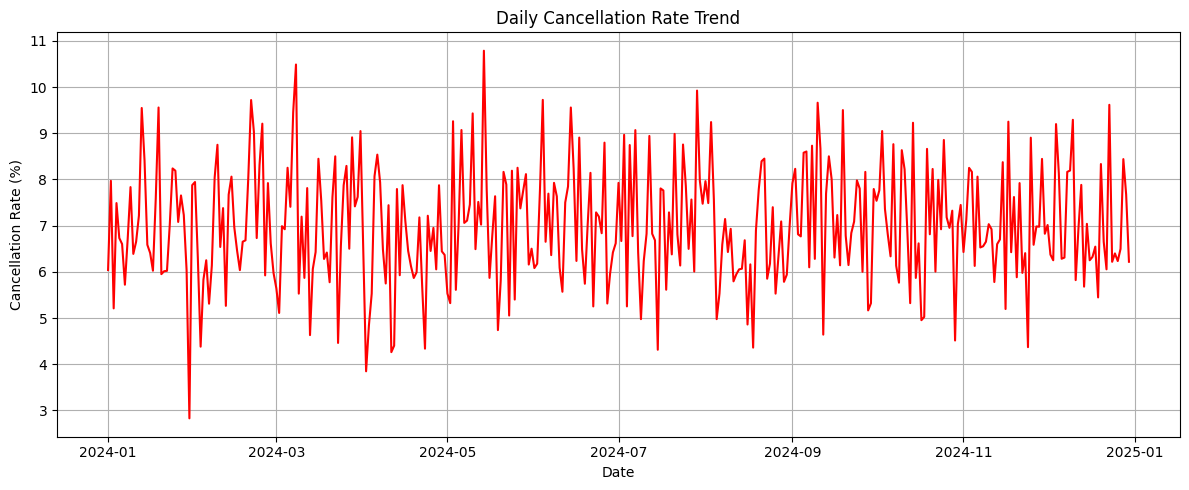

In [24]:
# Daily Cancellation Trend
daily_cancel = df.groupby('Date')['is_cancelled'].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(daily_cancel.index, daily_cancel.values, color='red', linewidth=1.5)
plt.title("Daily Cancellation Rate Trend")
plt.xlabel("Date")
plt.ylabel("Cancellation Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

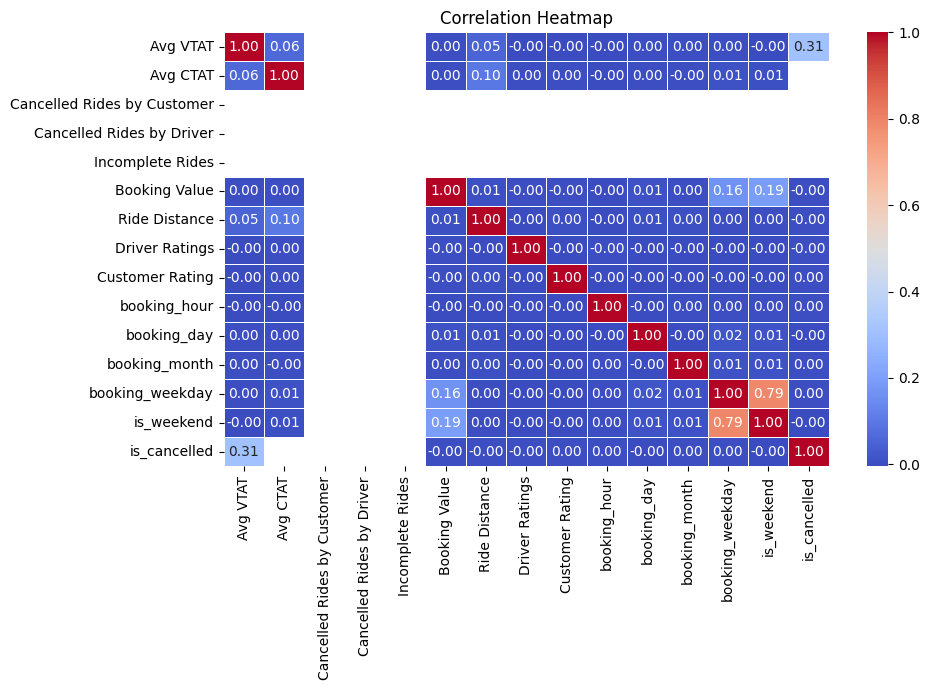

In [25]:
#Heatmap Analysis
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

** DAY 3 — Feature Engineering + Data Preparation**

In [26]:
#Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/uber_cleaned_day1.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Recreate is_cancelled cleanly
df['is_cancelled'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)

print("Shape:", df.shape)
print("Target:", df['is_cancelled'].value_counts().to_dict())

Shape: (150000, 27)
Target: {0: 139500, 1: 10500}


In [27]:
df = pd.get_dummies(df, columns=['Vehicle Type'], prefix='VType')
print("After encoding:", df.shape)

After encoding: (150000, 33)


In [28]:
#Frequency Encoding
pickup_freq = df['Pickup Location'].value_counts().to_dict()
drop_freq   = df['Drop Location'].value_counts().to_dict()

df['pickup_freq_encoded'] = df['Pickup Location'].map(pickup_freq)
df['drop_freq_encoded']   = df['Drop Location'].map(drop_freq)
print("Frequency encoding done")

Frequency encoding done


In [29]:
#Customer Booking Frequency
customer_freq = df['Customer ID'].value_counts().to_dict()
df['customer_booking_freq'] = df['Customer ID'].map(customer_freq)
print("Customer frequency feature done")
print(df['customer_booking_freq'].describe())

Customer frequency feature done
count    150000.000000
mean          1.016240
std           0.127344
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: customer_booking_freq, dtype: float64


In [30]:
vtype_cols = [col for col in df.columns if col.startswith('VType_')]

# IMPORTANT: Drop Avg CTAT, Payment Method, Customer Rating,
# Driver Ratings, Cancelled Rides columns → all cause leakage
safe_cols = [
    'Avg VTAT',
    'Booking Value',
    'Ride Distance',
    'booking_hour',
    'booking_day',
    'booking_month',
    'booking_weekday',
    'is_weekend',
    'customer_booking_freq',
    'pickup_freq_encoded',
    'drop_freq_encoded'
] + vtype_cols

df = df[safe_cols + ['is_cancelled']]
print("Safe columns:", df.columns.tolist())
print("Shape:", df.shape)

Safe columns: ['Avg VTAT', 'Booking Value', 'Ride Distance', 'booking_hour', 'booking_day', 'booking_month', 'booking_weekday', 'is_weekend', 'customer_booking_freq', 'pickup_freq_encoded', 'drop_freq_encoded', 'VType_Auto', 'VType_Bike', 'VType_Go Mini', 'VType_Go Sedan', 'VType_Premier Sedan', 'VType_Uber XL', 'VType_eBike', 'is_cancelled']
Shape: (150000, 19)


In [31]:
X = df.drop(columns=['is_cancelled'])
y = df['is_cancelled']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())
print(f"\nCancellation Rate: {y.mean()*100:.2f}%")

X shape: (150000, 18)
y distribution:
 is_cancelled
0    139500
1     10500
Name: count, dtype: int64

Cancellation Rate: 7.00%


In [32]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.5376344086021505), np.int64(1): np.float64(7.142857142857143)}


In [33]:
print("Correlation with target:")
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print(corr_with_target)

# Flag anything suspicious
print("\nHigh correlation columns (>0.5):")
high_corr = corr_with_target[corr_with_target > 0.5]
print(high_corr if len(high_corr) > 0 else "None No leakage detected!")

Correlation with target:
Avg VTAT                 3.057856e-01
VType_Go Sedan           4.606499e-03
VType_Auto               3.663573e-03
is_weekend               2.531856e-03
VType_Uber XL            2.398056e-03
drop_freq_encoded        1.697234e-03
VType_eBike              1.633388e-03
pickup_freq_encoded      1.536124e-03
booking_month            1.480393e-03
booking_hour             1.475095e-03
customer_booking_freq    1.329590e-03
booking_day              8.536638e-04
VType_Go Mini            6.927905e-04
booking_weekday          5.953065e-04
VType_Premier Sedan      1.419408e-04
VType_Bike               8.705126e-05
Ride Distance            7.994227e-17
Booking Value            1.984268e-17
dtype: float64

High correlation columns (>0.5):
None No leakage detected!


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (120000, 18)
Test size : (30000, 18)


In [35]:
# Fill missing values using notes methods
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    X_train[col].fillna(X_train[col].mean(), inplace=True)
    X_test[col].fillna(X_test[col].mean(), inplace=True)

print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test :", X_test.isnull().sum().sum())
print("Final shape:", X_train.shape)

X_train.to_csv("/content/X_train.csv", index=False)
X_test.to_csv("/content/X_test.csv",   index=False)
y_train.to_csv("/content/y_train.csv", index=False)
y_test.to_csv("/content/y_test.csv",   index=False)
print("ML-ready dataset saved!")

Missing in X_train: 0
Missing in X_test : 0
Final shape: (120000, 18)


/tmp/ipykernel_1536/949760755.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(X_train[col].mean(), inplace=True)
/tmp/ipykernel_1536/949760755.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

ML-ready dataset saved!


**DAY 4 — Model Building + Evaluation**

In [36]:
# Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

X_train = pd.read_csv("/content/X_train.csv")
X_test  = pd.read_csv("/content/X_test.csv")
y_train = pd.read_csv("/content/y_train.csv").squeeze()
y_test  = pd.read_csv("/content/y_test.csv").squeeze()

print("Data loaded")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Columns:", X_train.columns.tolist())

Data loaded
X_train: (120000, 18)
X_test : (30000, 18)
Columns: ['Avg VTAT', 'Booking Value', 'Ride Distance', 'booking_hour', 'booking_day', 'booking_month', 'booking_weekday', 'is_weekend', 'customer_booking_freq', 'pickup_freq_encoded', 'drop_freq_encoded', 'VType_Auto', 'VType_Bike', 'VType_Go Mini', 'VType_Go Sedan', 'VType_Premier Sedan', 'VType_Uber XL', 'VType_eBike']


In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]).round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     27900
           1       0.14      0.63      0.23      2100

    accuracy                           0.71     30000
   macro avg       0.55      0.68      0.53     30000
weighted avg       0.91      0.71      0.78     30000

ROC-AUC: 0.7626


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]).round(4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27900
           1       1.00      0.52      0.69      2100

    accuracy                           0.97     30000
   macro avg       0.98      0.76      0.83     30000
weighted avg       0.97      0.97      0.96     30000

ROC-AUC: 0.9624


In [39]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]).round(4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     27900
           1       0.37      0.91      0.52      2100

    accuracy                           0.88     30000
   macro avg       0.68      0.90      0.73     30000
weighted avg       0.95      0.88      0.91     30000

ROC-AUC: 0.9646


In [40]:
results = {
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, lr_pred, zero_division=0),
                  precision_score(y_test, rf_pred, zero_division=0),
                  precision_score(y_test, xgb_pred, zero_division=0)],
    'Recall'   : [recall_score(y_test, lr_pred),
                  recall_score(y_test, rf_pred),
                  recall_score(y_test, xgb_pred)],
    'F1-Score' : [f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, xgb_pred)],
    'ROC-AUC'  : [roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]),
                  roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
                  roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])]
}

results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7112     0.1442  0.6333    0.2349   0.7626
      Random Forest    0.9664     0.9982  0.5214    0.6850   0.9624
            XGBoost    0.8843     0.3679  0.9095    0.5239   0.9646


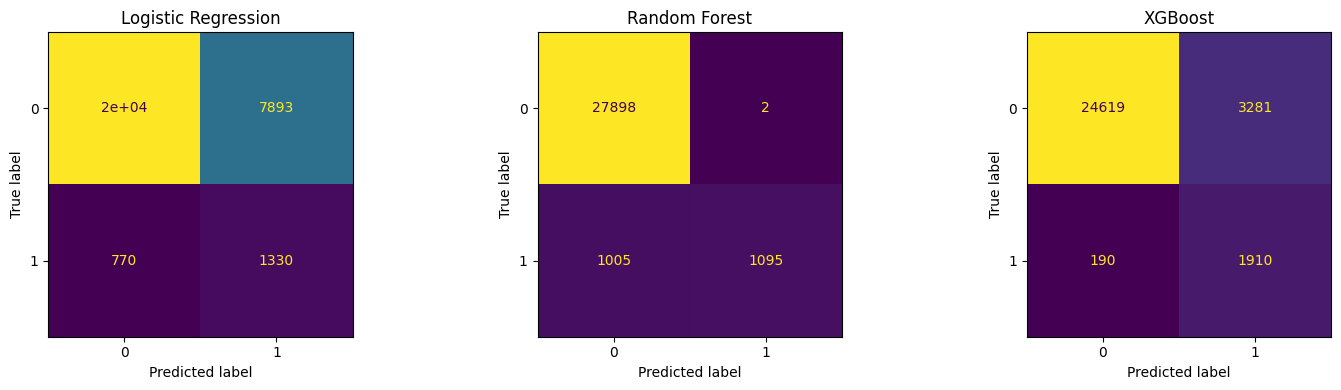

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pred, name in zip(axes,
                           [lr_pred, rf_pred, xgb_pred],
                           ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [51]:
my_ride = {
    'Avg VTAT'              : 5.2,
    'Booking Value'         : 250.0,
    'Ride Distance'         : 8.5,
    'booking_hour'          : 14,
    'booking_day'           : 15,
    'booking_month'         : 6,
    'booking_weekday'       : 0,
    'is_weekend'            : 0,
    'customer_booking_freq' : 5,
    'pickup_freq_encoded'   : 100,
    'drop_freq_encoded'     : 80,
    'VType_Auto'            : 0,
    'VType_Bike'            : 0,
    'VType_Go Mini'         : 0,
    'VType_Go Sedan'        : 1,
    'VType_Premier Sedan'   : 0,
    'VType_Uber XL'         : 0,
    'VType_eBike'           : 0,
}

my_ride_df = pd.DataFrame([my_ride])
my_ride_df = my_ride_df.reindex(columns=X_train.columns, fill_value=0)

result = rf_model.predict(my_ride_df)[0]

if result == 1:
    print("Customer CANCELLED the ride")
else:
    print("Ride was COMPLETED")

Ride was COMPLETED
